In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from  xgboost import XGBRegressor
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,mean_absolute_error


In [2]:
from sklearn.datasets import fetch_california_housing

house_price_data = fetch_california_housing()

In [3]:
df=pd.DataFrame(house_price_data.data,columns=house_price_data.feature_names)

In [4]:
df['price']=house_price_data.target

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.shape

(20640, 9)

In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [8]:
#statistical data
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
#understanding the correlation betwen the features
#1.positive correlation (one varivale increases then another variable also increases)
#2.negative correlation(on variable decreases then the other varibale also decreases)

correlation=df.corr()

<Axes: >

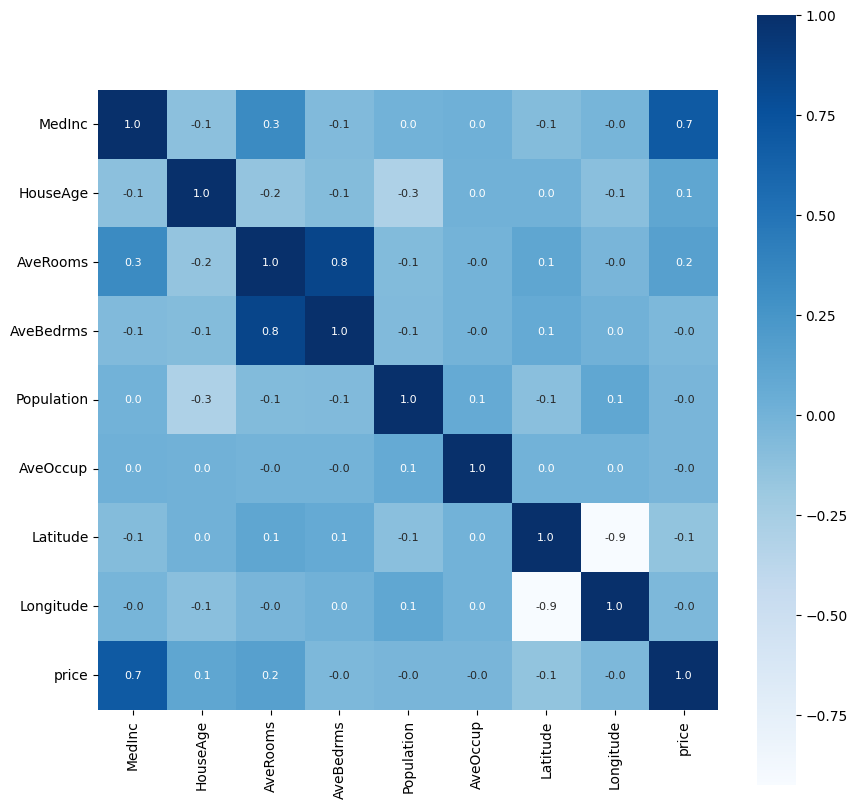

In [10]:
#constructing the heatmap to undersatnd the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':'8'},cmap='Blues')

In [11]:
X=df.drop(columns=['price'],axis=1)
y=df['price']

In [12]:
X.shape

(20640, 8)

In [13]:
y.shape

(20640,)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [29]:

print(X_train.shape,y_train.shape)

(16512, 8) (16512,)


In [30]:
#model training
#xgboost model is used it is ensemble model which used multiple decsion trees
model=XGBRegressor()

In [31]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [32]:
print(y_train.shape)
print(training_data_pred.shape)

(16512,)
(16512, 2)


In [34]:
training_data_pred = model.predict(X_train)

score_1 = r2_score(y_train, training_data_pred)

print(score_1)

0.943650140819218


In [40]:
score_2 = mean_absolute_error(y_train, training_data_pred)

print(score_1)

0.8338000331788725


In [42]:
test_data_pred = model.predict(X_test)

score_3 = r2_score(y_test, test_data_pred)

print(score_3)
score_4 = mean_absolute_error(y_test, test_data_pred)

print(score_4)

0.8338000331788725
0.3108631800268186


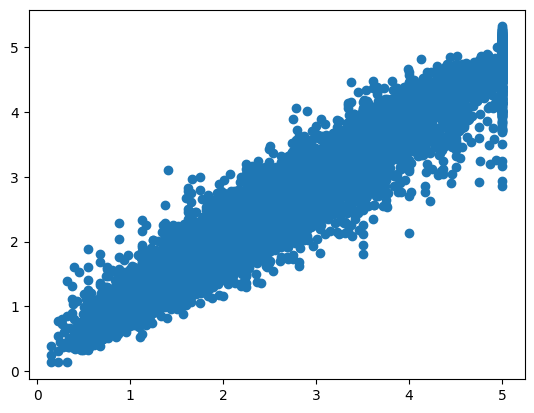

In [43]:
plt.scatter(y_train,training_data_pred)